In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('pneumologista_joao_pacientes.csv')

# Tratar nulos
df['saturacao_oxigenio'] = df['saturacao_oxigenio'].fillna(df['saturacao_oxigenio'].mean())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].median())
df['altura_m'] = df['altura_m'].fillna(df['altura_m'].median())

# Padronizar a coluna Sexo
def padronizar_sexo(valor):
    valor = str(valor).upper().strip()
    if valor in ['MASCULINO', 'MASC', 'M']: return 'M'
    if valor in ['FEMININO', 'FEM', 'F']: return 'F'
    return 'Outro' # Para o "Não declarado"

df['sexo'] = df['sexo'].apply(padronizar_sexo)

#  Validar IMC (Peso / Altura²)
df['imc_calculado'] = df['peso_kg'] / (df['altura_m'] ** 2)


df = df[df['saturacao_oxigenio'] < 1000]

# Corrigir escala
df['saturacao_oxigenio'] = df['saturacao_oxigenio'].apply(
    lambda x: x / 10 if x > 100 else x
)

#Filtrar valores realistas
df = df[(df['saturacao_oxigenio'] >= 85) &
        (df['saturacao_oxigenio'] <= 100)]


# Salvar aquirvo limpo
df.to_csv('pacientes_clinica_limpo.csv', index=False)
print("ETL Concluído. Arquivo limpo salvo!")

ETL Concluído. Arquivo limpo salvo!


--- RELATÓRIO CLÍNICO (RESUMO) ---
Média do IMC: 27.14 | Desvio Padrão: 6.12
Média da Saturação de O2: 96.45%



/tmp/ipykernel_4656/1868561292.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=contagem_faixa.index, y=contagem_faixa.values,


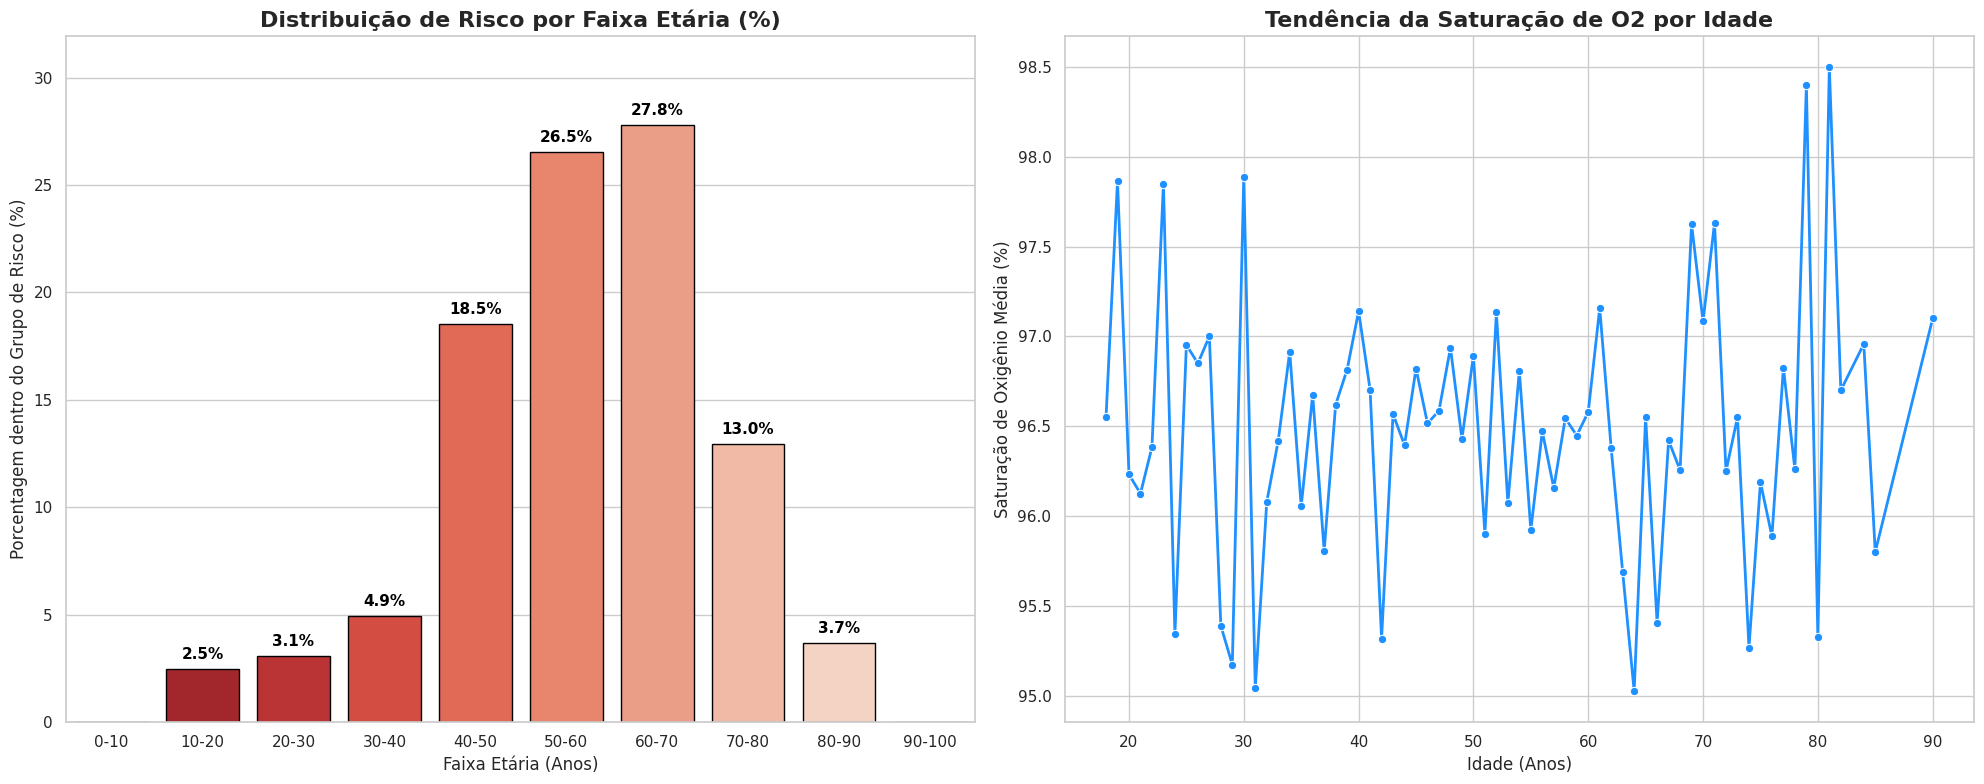


--- INICIANDO TREINAMENTO DA IA ---

 RESULTADO FINAL DA INTELIGÊNCIA ARTIFICIAL
 ACURÁCIA GERAL DO MODELO: 88.33%

Relatório de Performance Detalhado:
              precision    recall  f1-score   support

       Risco       0.80      0.56      0.66        36
   Sem Risco       0.90      0.97      0.93       144

    accuracy                           0.88       180
   macro avg       0.85      0.76      0.79       180
weighted avg       0.88      0.88      0.87       180



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. CARREGAR DADOS LIMPOS
# ==========================================
# Lendo o arquivo que você gerou na etapa anterior
try:
    df_clean = pd.read_csv('pacientes_clinica_limpo.csv')
except FileNotFoundError:
    print("Erro: O arquivo 'pacientes_clinica_limpo.csv' não foi encontrado.")
    print("Certifique-se de rodar o código de ETL primeiro.")
    # Para evitar erros nos próximos passos se o arquivo não existir
    exit()

# ==========================================
# 2. ESTATÍSTICA (NumPy)
# ==========================================
# Média e desvio padrão do IMC calculado
media_imc = np.mean(df_clean['imc_calculado'])
desvio_imc = np.std(df_clean['imc_calculado'])

# Média da Saturação de O2
media_o2 = np.mean(df_clean['saturacao_oxigenio'])

print(f"--- RELATÓRIO CLÍNICO (RESUMO) ---")
print(f"Média do IMC: {media_imc:.2f} | Desvio Padrão: {desvio_imc:.2f}")
print(f"Média da Saturação de O2: {media_o2:.2f}%\n")

# ==========================================
# 3. VISUALIZAÇÃO COMBINADA (Idade: Barras e Linha)
# ==========================================
sns.set(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# --- GRÁFICO 1: Barras (Distribuição de Risco por Faixa Etária) ---
# Preparação dos dados
df_risco = df_clean[df_clean['risco_cancer_pulmao'] == 'Risco'].copy()
bins = list(range(0, 110, 10))
labels = [f'{i}-{i+10}' for i in range(0, 100, 10)]
df_risco['faixa_etaria'] = pd.cut(df_risco['idade'], bins=bins, labels=labels, right=False)
contagem_faixa = df_risco['faixa_etaria'].value_counts(normalize=True).sort_index() * 100

# Plotagem das barras
barplot = sns.barplot(x=contagem_faixa.index, y=contagem_faixa.values,
                      palette='Reds_r', ax=ax[0], edgecolor='black')

for p in barplot.patches:
    height = p.get_height()
    if height > 0: # Só adiciona rótulo se a barra tiver altura
        barplot.annotate(f'{height:.1f}%',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom',
                         xytext=(0, 5), # Afasta o texto 5 pontos para cima da barra
                         textcoords='offset points',
                         fontweight='bold', fontsize=11, color='black')

ax[0].set_title('Distribuição de Risco por Faixa Etária (%)', fontsize=16, fontweight='bold')
ax[0].set_ylabel('Porcentagem dentro do Grupo de Risco (%)', fontsize=12)
ax[0].set_xlabel('Faixa Etária (Anos)', fontsize=12)
# Ajusta o limite do eixo Y para o texto não cortar no topo
ax[0].set_ylim(0, max(contagem_faixa.values) * 1.15)

# --- GRÁFICO 2: Linha (Tendência de O2 por Idade) ---
tendencia_o2 = df_clean.groupby('idade')['saturacao_oxigenio'].mean().reset_index()
sns.lineplot(data=tendencia_o2, x='idade', y='saturacao_oxigenio',
             ax=ax[1], color='dodgerblue', marker='o', linewidth=2)
ax[1].set_title('Tendência da Saturação de O2 por Idade', fontsize=16, fontweight='bold')
ax[1].set_ylabel('Saturação de Oxigênio Média (%)', fontsize=12)
ax[1].set_xlabel('Idade (Anos)', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 4. MACHINE LEARNING (Classificação)
# ==========================================

print("\n--- INICIANDO TREINAMENTO DA IA ---")

# Preparação dos dados: Removendo colunas desnecessárias para a previsão
X = df_clean.drop(columns=['nome_paciente', 'risco_cancer_pulmao', 'imc_calculado']) # removemos o imc_calculado se ele causa vazamento
y = df_clean['risco_cancer_pulmao']

# Codificando variáveis categóricas (Texto -> Número)
le = LabelEncoder()
colunas_categoricas = X.select_dtypes(include=['object']).columns
for col in colunas_categoricas:
    X[col] = le.fit_transform(X[col])

# Divisão Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e Treinando o Modelo (Random Forest)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Resultado Final
previsoes = modelo.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)

print("\n" + "="*50)
print(f" RESULTADO FINAL DA INTELIGÊNCIA ARTIFICIAL")
print(f" ACURÁCIA GERAL DO MODELO: {acuracia * 100:.2f}%")
print("="*50)
print("\nRelatório de Performance Detalhado:")
# Mapeando os nomes das classes para o relatório
target_names = le.classes_ if 'le' in locals() else None
print(classification_report(y_test, previsoes))